### Calculate motion of 2 coupled non-reciprocal pendula

(2, 2)


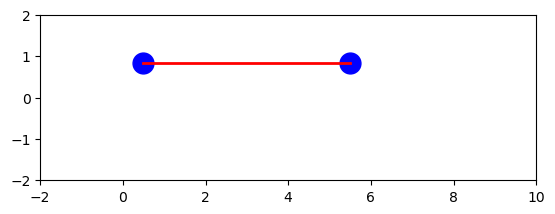

In [84]:
from numpy import array, cos, sin, shape, vstack
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.pyplot import plot, show

w = 1
gamma = 0.1
sigma = 1
beta = 1
ro = 1
time_steps = 100
lc = 5 # lattice constant
dt = 0.01
M = array([[-gamma, -beta, 0, sigma, 0, beta, 0, 0], [beta, -gamma, -sigma, 
  0, -beta, 0, 0, 0], [0, -sigma, -gamma, -ro, 0, 0, 0, ro], [sigma, 
  0, ro, -gamma, 0, 0, -ro, 0], [0, beta, 0, 0, -gamma, -beta, 0, 
  sigma], [-beta, 0, 0, 0, beta, -gamma, -sigma, 0], [0, 0, 0, ro, 
  0, -sigma, -gamma, -ro], [0, 0, -ro, 0, sigma, 0, ro, -gamma]], float)
t = 0

def position_pendula(a, t):
    p1 = array([a[0]*cos(w*t)+a[1]*sin(w*t), a[2]*cos(w*t)+a[3]*sin(w*t)])
    p2 = array([lc + a[4]*cos(w*t)+a[5]*sin(w*t), a[6]*cos(w*t)+a[7]*sin(w*t)])
    pos = vstack([[p1], [p2]])
    return pos

# Set up the figure
fig, ax = plt.subplots()
ax.set_xlim(-2, 10)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')

# Initialize particles (positions and velocities)
A = array([1,0,0,0,1,0,0,0], float)
pos = position_pendula(A, t)
print(shape(pos))

# Create plot objects
particles, = ax.plot([], [], 'bo', markersize=15)
spring, = ax.plot([], [], 'r-', linewidth=2)

def update(frame):
    A = array([1,0,0,0,1,0,0,0], float)
    t = 0
    A+= M.dot(A)
    t+=1
    pos = position_pendula(A, t)
    particles.set_data(pos[:, 0], pos[:, 1])
    spring.set_data(pos[:, 0], pos[:, 1])
    return particles, spring

animation = FuncAnimation(fig, update, frames=200, interval=50, blit=True)

plt.show()

### My code: simulate a Lieb lattice with Yuan's cubes.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import taichi as ti

ti.init(arch=ti.cpu)

# Constants
a = 1.0  # lattice constant
m = 1.0  # mass
k1 = 1e1  # spring constant within cubes (node connections)
k2 = 5.0  # spring constant between cubes
eta = 2 * np.sqrt(k2 * m) * 0.1  # viscous damping
ko = 5.0  # non-reciprocal spring constant magnitude

# Non-reciprocal parameters for altermagnetic sites
# + sites: clockwise gain (+ko), - sites: anticlockwise gain (-ko), nonmagnetic: 0
amp = 1e-2  # perturbation amplitude
omega = np.sqrt(k1 / m)  # frequency

periodicity = 2 * np.pi / omega
t_step = 20
dt = periodicity / t_step
print(f"Time step: {dt}")

# Gravity (optional)
g = 0.0
gx, gy, gz = g, 0.0, 0.0

# Lieb lattice parameters
n_cubes_x, n_cubes_y = 5, 5  # number of unit cells
# Lieb lattice has 3 sites per unit cell: A(+), B(nonmagnetic), C(-)
sites_per_unit_cell = 3

[Taichi] Starting on arch=x64
Time step: 0.099345882657961


In [15]:
@ti.data_oriented
class AltermagneticLiebLattice:
    def __init__(self, n_cubes_x, n_cubes_y, a=1.0):
        self.n_cubes_x = n_cubes_x
        self.n_cubes_y = n_cubes_y
        self.a = a
        self.total_cubes = n_cubes_x * n_cubes_y * 3  # 3 sites per unit cell
        
        # Initialize cube fields
        self.cube_pos = ti.Vector.field(3, dtype=ti.f32, shape=(self.total_cubes,))
        self.cube_type = ti.field(dtype=ti.i32, shape=(self.total_cubes,))
        
        # Initialize spring fields
        self.spring_i = ti.field(dtype=ti.i32, shape=(4 * self.total_cubes,))
        self.spring_j = ti.field(dtype=ti.i32, shape=(4 * self.total_cubes,))
        self.spring_nonreciprocal = ti.field(dtype=ti.i32, shape=(4 * self.total_cubes,))
        self.spring_direction = ti.field(dtype=ti.i32, shape=(4 * self.total_cubes,))
        
        self.spring_count = ti.field(ti.i32, shape=())
        
        self.initialize_lattice()
        self.initialize_springs()
    
    @ti.kernel
    def initialize_lattice(self):
        cube_idx = 0
        for i in range(self.n_cubes_x):
            for j in range(self.n_cubes_y):
                # Unit cell positions
                x_base = i * 2 * self.a
                y_base = j * 2 * self.a
                
                # Site A: + site (clockwise)
                self.cube_pos[cube_idx] = ti.Vector([x_base, y_base, 0.0])
                self.cube_type[cube_idx] = 1  # clockwise
                cube_idx += 1
                
                # Site B: nonmagnetic site
                self.cube_pos[cube_idx] = ti.Vector([x_base + self.a, y_base, 0.0])
                self.cube_type[cube_idx] = 0  # nonmagnetic
                cube_idx += 1
                
                # Site C: - site (anticlockwise)
                self.cube_pos[cube_idx] = ti.Vector([x_base + self.a, y_base + self.a, 0.0])
                self.cube_type[cube_idx] = 2  # anticlockwise
                cube_idx += 1
    
    @ti.kernel
    def initialize_springs(self):
        spring_idx = 0
        
        for i in range(self.total_cubes):
            pos_i = self.cube_pos[i]
            type_i = self.cube_type[i]
            
            for j in range(i + 1, self.total_cubes):
                pos_j = self.cube_pos[j]
                type_j = self.cube_type[j]
                
                dist = (pos_i - pos_j).norm()
                
                # Connect nearest neighbors
                if dist < 1.5 * self.a:
                    self.spring_i[spring_idx] = i
                    self.spring_j[spring_idx] = j
                    
                    # Determine non-reciprocal behavior
                    if type_i == 1 and type_j == 0:  # + to nonmagnetic
                        self.spring_nonreciprocal[spring_idx] = 1
                        self.spring_direction[spring_idx] = 1
                    elif type_i == 0 and type_j == 1:  # nonmagnetic to +
                        self.spring_nonreciprocal[spring_idx] = 1
                        self.spring_direction[spring_idx] = 2
                    elif type_i == 2 and type_j == 0:  # - to nonmagnetic
                        self.spring_nonreciprocal[spring_idx] = 1
                        self.spring_direction[spring_idx] = 2
                    elif type_i == 0 and type_j == 2:  # nonmagnetic to -
                        self.spring_nonreciprocal[spring_idx] = 1
                        self.spring_direction[spring_idx] = 1
                    else:
                        self.spring_nonreciprocal[spring_idx] = 0
                        self.spring_direction[spring_idx] = 0
                    
                    spring_idx += 1
        
        self.spring_count[None] = spring_idx
    
    def print_lattice_info(self):
        """Print detailed information about the lattice"""
        print("=" * 50)
        print("LATTICE STRUCTURE VERIFICATION")
        print("=" * 50)
        
        # Get data as numpy arrays
        pos_np = self.cube_pos.to_numpy()
        type_np = self.cube_type.to_numpy()
        spring_count = self.spring_count[None]
        
        print(f"Total cubes: {self.total_cubes}")
        print(f"Unit cells: {self.n_cubes_x} x {self.n_cubes_y}")
        print(f"Total springs: {spring_count}")
        print()
        
        # Count site types
        type_counts = {0: 0, 1: 0, 2: 0}
        for i in range(self.total_cubes):
            type_counts[type_np[i]] += 1
        
        print("Site type distribution:")
        print(f"  Nonmagnetic (N): {type_counts[0]} sites")
        print(f"  Clockwise (+): {type_counts[1]} sites")  
        print(f"  Anticlockwise (-): {type_counts[2]} sites")
        print()
        
        # Print unit cell structure
        print("Unit cell structure (first 3 unit cells):")
        for cell in range(min(3, self.n_cubes_x * self.n_cubes_y)):
            base_idx = cell * 3
            print(f"  Unit cell {cell}:")
            for site in range(3):
                idx = base_idx + site
                x, y, z = pos_np[idx]
                site_type = type_np[idx]
                type_str = "N" if site_type == 0 else "+" if site_type == 1 else "-"
                print(f"    Site {site}: ({x:.1f}, {y:.1f}) - Type: {type_str}")
        print()
        
        # Print spring information
        print("Spring connections (first 10 springs):")
        for s in range(min(10, spring_count)):
            i = self.spring_i[s]
            j = self.spring_j[s]
            type_i = type_np[i]
            type_j = type_np[j]
            nonrecip = self.spring_nonreciprocal[s]
            direction = self.spring_direction[s]
            
            type_str_i = "N" if type_i == 0 else "+" if type_i == 1 else "-"
            type_str_j = "N" if type_j == 0 else "+" if type_j == 1 else "-"
            
            spring_type = "Reciprocal"
            if nonrecip == 1:
                if direction == 1:
                    spring_type = f"{type_str_i}→{type_str_j}: k12=+ko, k21=-ko"
                else:
                    spring_type = f"{type_str_i}→{type_str_j}: k12=-ko, k21=+ko"
            
            pos_i = pos_np[i]
            pos_j = pos_np[j]
            dist = np.linalg.norm(pos_i - pos_j)
            
            print(f"  Spring {s}: {type_str_i}({i}) ↔ {type_str_j}({j}) | "
                  f"Dist: {dist:.2f} | Type: {spring_type}")
    
    def plot_lattice_structure(self):
        """Plot the lattice structure with detailed annotations"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Get data
        pos_np = self.cube_pos.to_numpy()
        type_np = self.cube_type.to_numpy()
        spring_count = self.spring_count[None]
        
        # Plot 1: Basic lattice structure
        colors = ['blue', 'red', 'green']
        markers = ['s', '^', 'v']
        labels = ['Nonmagnetic (N)', 'Clockwise (+)', 'Anticlockwise (-)']
        
        for site_type in [0, 1, 2]:
            mask = type_np == site_type
            x = pos_np[mask, 0]
            y = pos_np[mask, 1]
            ax1.scatter(x, y, c=colors[site_type], marker=markers[site_type], 
                       s=100, label=labels[site_type], alpha=0.8)
            
            # Add labels for some sites
            for i in range(len(x)):
                if i % 3 == 0:  # Label one site per unit cell
                    label = 'N' if site_type == 0 else '+' if site_type == 1 else '-'
                    ax1.text(x[i], y[i] + 0.15, label, 
                            ha='center', va='bottom', fontweight='bold')
        
        # Draw springs
        for s in range(spring_count):
            i = self.spring_i[s]
            j = self.spring_j[s]
            pos_i = pos_np[i]
            pos_j = pos_np[j]
            
            # Determine spring style
            if self.spring_nonreciprocal[s] == 1:
                if self.spring_direction[s] == 1:
                    color = 'orange'
                    linestyle = '--'
                    width = 2.0
                else:
                    color = 'purple' 
                    linestyle = ':'
                    width = 2.0
            else:
                color = 'gray'
                linestyle = '-'
                width = 1.0
            
            ax1.plot([pos_i[0], pos_j[0]], [pos_i[1], pos_j[1]], 
                    color=color, linestyle=linestyle, linewidth=width, alpha=0.7)
        
        ax1.set_aspect('equal')
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        ax1.set_title('Altermagnetic Lieb Lattice Structure')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Unit cell highlighting
        for site_type in [0, 1, 2]:
            mask = type_np == site_type
            x = pos_np[mask, 0]
            y = pos_np[mask, 1]
            ax2.scatter(x, y, c=colors[site_type], marker=markers[site_type], 
                       s=100, label=labels[site_type], alpha=0.8)
        
        # Highlight one unit cell
        if self.n_cubes_x > 0 and self.n_cubes_y > 0:
            # First unit cell
            base_x, base_y = 0, 0
            unit_cell_points = [
                (base_x, base_y),           # + site
                (base_x + a, base_y),       # N site  
                (base_x, base_y + a)        # - site
            ]
            
            # Draw unit cell boundary
            unit_cell_rect = plt.Rectangle((base_x - 0.1, base_y - 0.1), 
                                         2*a + 0.2, 2*a + 0.2,
                                         fill=False, edgecolor='red', 
                                         linewidth=2, linestyle='--')
            ax2.add_patch(unit_cell_rect)
            
            # Label unit cell components
            ax2.text(base_x + a, base_y + a, 'Unit Cell', 
                    ha='center', va='center', fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            
            # Add arrows showing non-reciprocal directions
            arrow_params = dict(width=0.02, head_width=0.1, head_length=0.1, 
                              fc='red', ec='red', alpha=0.7)
            
            # + to N direction
            ax2.arrow(base_x, base_y, a*0.7, 0, **arrow_params)
            # N to - direction  
            ax2.arrow(base_x + a, base_y, -a*0.3, a*0.7, **arrow_params)
            # - to + direction
            ax2.arrow(base_x, base_y + a, 0, -a*0.7, **arrow_params)
        
        ax2.set_aspect('equal')
        ax2.set_xlabel('X')
        ax2.set_ylabel('Y')
        ax2.set_title('Unit Cell Structure with Non-reciprocal Directions')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return fig

In [16]:

# Create and initialize the lattice
lattice = AltermagneticLiebLattice(n_cubes_x, n_cubes_y, a)


LATTICE STRUCTURE VERIFICATION
Total cubes: 75
Unit cells: 5 x 5
Total springs: 171

Site type distribution:
  Nonmagnetic (N): 25 sites
  Clockwise (+): 25 sites
  Anticlockwise (-): 25 sites

Unit cell structure (first 3 unit cells):
  Unit cell 0:
    Site 0: (0.0, 0.0) - Type: +
    Site 1: (1.0, 0.0) - Type: N
    Site 2: (1.0, 1.0) - Type: -
  Unit cell 1:
    Site 0: (0.0, 2.0) - Type: +
    Site 1: (1.0, 2.0) - Type: N
    Site 2: (1.0, 3.0) - Type: -
  Unit cell 2:
    Site 0: (0.0, 4.0) - Type: +
    Site 1: (1.0, 4.0) - Type: N
    Site 2: (1.0, 5.0) - Type: -

Spring connections (first 10 springs):
  Spring 0: +(0) ↔ N(1) | Dist: 1.00 | Type: +→N: k12=+ko, k21=-ko
  Spring 1: +(0) ↔ -(2) | Dist: 1.41 | Type: Reciprocal
  Spring 2: N(1) ↔ -(2) | Dist: 1.00 | Type: N→-: k12=+ko, k21=-ko
  Spring 3: N(1) ↔ +(15) | Dist: 1.00 | Type: N→+: k12=-ko, k21=+ko
  Spring 4: -(2) ↔ +(3) | Dist: 1.41 | Type: Reciprocal
  Spring 5: -(2) ↔ N(4) | Dist: 1.00 | Type: -→N: k12=-ko, k21=+ko
 

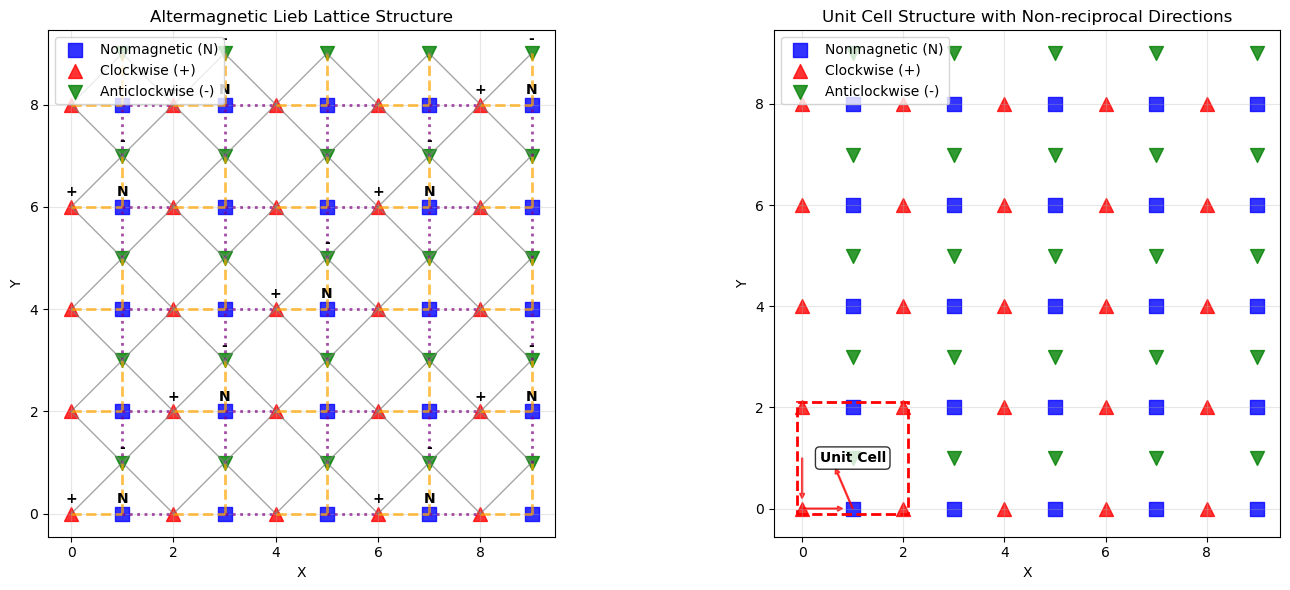


ADDITIONAL CHECKS
Checking Lieb lattice symmetry...
  Unit cell (0,0): ✓ Correct
  Unit cell (0,1): ✓ Correct
  Unit cell (0,2): ✓ Correct
  Unit cell (0,3): ✓ Correct
  Unit cell (0,4): ✓ Correct
  Unit cell (1,0): ✓ Correct
  Unit cell (1,1): ✓ Correct
  Unit cell (1,2): ✓ Correct
  Unit cell (1,3): ✓ Correct
  Unit cell (1,4): ✓ Correct
  Unit cell (2,0): ✓ Correct
  Unit cell (2,1): ✓ Correct
  Unit cell (2,2): ✓ Correct
  Unit cell (2,3): ✓ Correct
  Unit cell (2,4): ✓ Correct
  Unit cell (3,0): ✓ Correct
  Unit cell (3,1): ✓ Correct
  Unit cell (3,2): ✓ Correct
  Unit cell (3,3): ✓ Correct
  Unit cell (3,4): ✓ Correct
  Unit cell (4,0): ✓ Correct
  Unit cell (4,1): ✓ Correct
  Unit cell (4,2): ✓ Correct
  Unit cell (4,3): ✓ Correct
  Unit cell (4,4): ✓ Correct


In [18]:
# Print detailed information
lattice.print_lattice_info()

# Plot the structure
fig = lattice.plot_lattice_structure()

# Additional verification
print("\n" + "="*50)
print("ADDITIONAL CHECKS")
print("="*50)

pos_np = lattice.cube_pos.to_numpy()
type_np = lattice.cube_type.to_numpy()

# Check Lieb lattice symmetry
print("Checking Lieb lattice symmetry...")
for i in range(lattice.n_cubes_x):
    for j in range(lattice.n_cubes_y):
        cell_idx = (i * lattice.n_cubes_y + j) * 3
        sites = pos_np[cell_idx:cell_idx+3]
        types = type_np[cell_idx:cell_idx+3]
        
        # Check positions form an L-shape
        expected_positions = [
            [i*2*a, j*2*a, 0],      # + site
            [i*2*a + a, j*2*a, 0],  # N site
            [i*2*a + a, j*2*a + a, 0]   # - site
        ]
        
        positions_match = all(np.allclose(actual, expected, atol=1e-6) 
                            for actual, expected in zip(sites, expected_positions))
        
        # Check site types
        types_match = (types[0] == 1 and types[1] == 0 and types[2] == 2)
        
        if positions_match and types_match:
            print(f"  Unit cell ({i},{j}): ✓ Correct")
        else:
            print(f"  Unit cell ({i},{j}): ✗ ERROR - Check implementation")

In [ ]:

# Add small initial perturbation
@ti.kernel
def add_perturbation():
    for i in range(lattice.total_cubes):
        lattice.cube_vel[i] = ti.Vector([amp * ti.sin(i * 0.1), amp * ti.cos(i * 0.1), 0.0])

add_perturbation()

# Simulation loop
fig, ax = plt.subplots(figsize=(10, 8))

for step in range(100):
    lattice.step()
    
    if step % 10 == 0:
        print(f"Step {step}")
        lattice.visualize(ax)
        plt.pause(0.1)

plt.show()

# Print lattice information
print(f"Total cubes: {lattice.total_cubes}")
print(f"Total springs: {lattice.spring_count[None]}")
print("Site types: + (clockwise), - (anticlockwise), N (nonmagnetic)")